In [1]:
from pathlib import Path
import csv, math
import matplotlib.pyplot as plt

BASE = Path().resolve()
TRADE_LOG_CSV = BASE / "data" / "trade_log.csv"  # or BASE/"data"/"trade_log.csv"
RESULTS_CSV   = BASE / "outputs" / "ExecutionResults.csv"

In [2]:
def read_trade_log(path: Path):
    """
    Required columns (case-insensitive):
      Ticker, Date, Side, OrderQty, Price, Volume
    Side ∈ {'BUY','SELL'}
    """
    rows = []
    with path.open("r", newline="") as f:
        r = csv.DictReader(f)
        for row in r:
            row = {k.strip().lower(): v for k, v in row.items()}
            rows.append({
                "Ticker": row["ticker"].upper(),
                "Date":   row["date"],
                "Side":   row["side"].upper(),
                "OrderQty": int(float(row["orderqty"])),
                "Price":    float(row["price"]),
                "Volume":   int(float(row["volume"])),
            })
    return rows

def write_results(path: Path, rows):
    path.parent.mkdir(parents=True, exist_ok=True)
    fields = ["Ticker","Date","Side","RequestedQty","FilledQty","AvgFillPrice",
              "RefPrice","SlippagePerShare","PnL_Realized"]
    with path.open("w", newline="") as f:
        w = csv.DictWriter(f, fieldnames=fields)
        w.writeheader()
        w.writerows(rows)

In [3]:
def compute_slippage(price: float, order_qty: int, volume: int) -> float:
    """
    slip = price * (0.0005 * order_size / volume)
    """
    if volume <= 0 or order_qty <= 0:
        return 0.0
    return price * (0.0005 * (order_qty / max(1, volume)))

def cap_liquidity(order_qty: int, volume: int, pov_cap: float = 0.10) -> int:
    """
    Cap fills if order size > volume * 0.1
    """
    cap = int(math.floor(pov_cap * max(0, volume)))
    return max(0, min(order_qty, cap))

def execute_log(trades):
    """
    Tracks average cost per ticker; realizes PnL when position is reduced.
    Returns list of per-trade results and final positions dict.
    """
    results = []
    position = {}      # {ticker: {"qty": int, "avg_cost": float}}
    realized_pnl = 0.0 # total realized (we also return per-trade)

    for t in trades:
        sym   = t["Ticker"]; side = t["Side"]
        order = int(t["OrderQty"]); ref_px = float(t["Price"]); vol = int(t["Volume"])

        # Liquidity cap
        fill_qty = cap_liquidity(order, vol, pov_cap=0.10)

        # Slippage and fill price
        slip_ps  = compute_slippage(ref_px, fill_qty, vol)   # per-share slip
        if side == "BUY":
            fill_px = ref_px + slip_ps
            signed_qty = +fill_qty
        else:
            fill_px = ref_px - slip_ps
            signed_qty = -fill_qty

        # Position & realized PnL with average-cost accounting
        pos = position.get(sym, {"qty": 0, "avg_cost": 0.0})
        qty0, avg0 = pos["qty"], pos["avg_cost"]
        trade_realized = 0.0

        if signed_qty > 0:  # BUY increases position; update avg cost
            new_qty = qty0 + signed_qty
            if new_qty != 0:
                if qty0 >= 0:
                    # blend costs
                    avg_new = (qty0*avg0 + signed_qty*fill_px) / new_qty
                else:
                    # covering shorts first: realize PnL on the covered portion
                    cover = min(signed_qty, -qty0)
                    if cover > 0:
                        trade_realized += (avg0 - fill_px) * cover  # closing short
                    remaining_buy = signed_qty - cover
                    if qty0 + signed_qty >= 0:
                        # moved to long or flat -> new avg is fill_px on remaining long
                        basis_qty = max(0, qty0 + signed_qty)
                        avg_new = fill_px if basis_qty > 0 else 0.0
                    else:
                        # still short (unlikely with buy), keep avg0
                        avg_new = avg0
            else:
                avg_new = 0.0
            position[sym] = {"qty": new_qty, "avg_cost": avg_new}

        elif signed_qty < 0:  # SELL decreases position or opens short
            sell_qty = -signed_qty
            if qty0 > 0:
                close = min(sell_qty, qty0)
                if close > 0:
                    trade_realized += (fill_px - avg0) * close
                remaining_sell = sell_qty - close
                new_qty = qty0 - sell_qty
                avg_new = avg0 if new_qty > 0 else fill_px if new_qty < 0 else 0.0
            else:
                # opening/increasing short
                new_qty = qty0 - sell_qty
                avg_new = fill_px
            position[sym] = {"qty": new_qty, "avg_cost": avg_new}

        realized_pnl += trade_realized

        results.append({
            "Ticker": sym,
            "Date": t["Date"],
            "Side": side,
            "RequestedQty": order,
            "FilledQty": fill_qty,
            "AvgFillPrice": round(fill_px, 4),
            "RefPrice": round(ref_px, 4),
            "SlippagePerShare": round((fill_px - ref_px) if side=="BUY" else (ref_px - fill_px), 6),
            "PnL_Realized": round(trade_realized, 4),
        })

    return results, position, realized_pnl

In [4]:
trades = read_trade_log(TRADE_LOG_CSV)
results, positions, total_realized = execute_log(trades)
write_results(RESULTS_CSV, results)
print(f"Wrote {len(results)} rows -> {RESULTS_CSV}")
print("Final positions:", positions)
print("Total realized PnL:", round(total_realized, 4))
# Show first few rows nicely
results[:5]

Wrote 4 rows -> /Users/chrisroukis/Desktop/GT3rdYr/Data_Science_Club/execution/outputs/ExecutionResults.csv
Final positions: {'AAPL': {'qty': 5000, 'avg_cost': 175.00072916666667}, 'MSFT': {'qty': 4000, 'avg_cost': 318.20129877551017}}
Total realized PnL: 13586.273


[{'Ticker': 'AAPL',
  'Date': '2025-01-01',
  'Side': 'BUY',
  'RequestedQty': 10000,
  'FilledQty': 10000,
  'AvgFillPrice': 175.0007,
  'RefPrice': 175.0,
  'SlippagePerShare': 0.000729,
  'PnL_Realized': 0.0},
 {'Ticker': 'AAPL',
  'Date': '2025-01-02',
  'Side': 'SELL',
  'RequestedQty': 5000,
  'FilledQty': 5000,
  'AvgFillPrice': 176.1995,
  'RefPrice': 176.2,
  'SlippagePerShare': 0.000489,
  'PnL_Realized': 5993.9069},
 {'Ticker': 'MSFT',
  'Date': '2025-01-01',
  'Side': 'BUY',
  'RequestedQty': 8000,
  'FilledQty': 8000,
  'AvgFillPrice': 318.2013,
  'RefPrice': 318.2,
  'SlippagePerShare': 0.001299,
  'PnL_Realized': 0.0},
 {'Ticker': 'MSFT',
  'Date': '2025-01-02',
  'Side': 'SELL',
  'RequestedQty': 4000,
  'FilledQty': 4000,
  'AvgFillPrice': 320.0994,
  'RefPrice': 320.1,
  'SlippagePerShare': 0.00061,
  'PnL_Realized': 7592.366}]

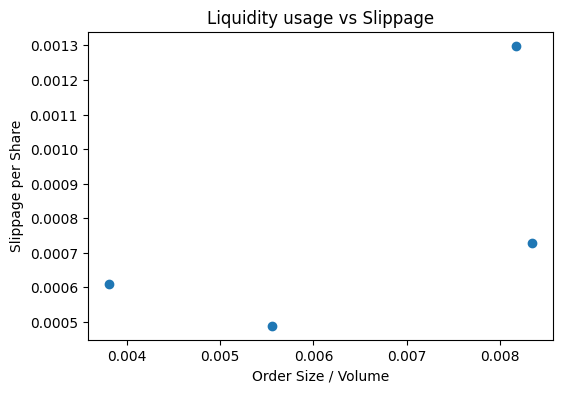

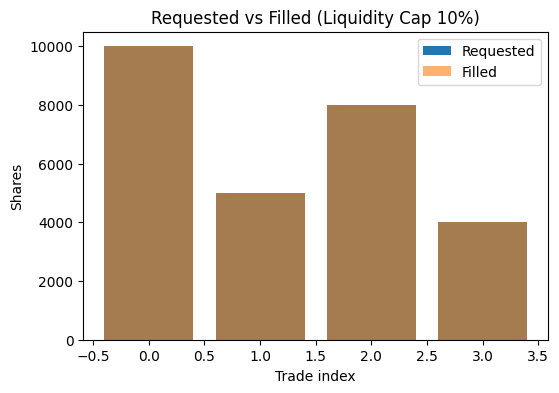

In [5]:
# Build simple arrays
rq = [r["RequestedQty"] for r in results]
fq = [r["FilledQty"] for r in results]
liq_frac = [ (r["FilledQty"] / max(1, next(t["Volume"] for t in trades if t["Ticker"]==r["Ticker"] and t["Date"]==r["Date"]))) for r in results ]
slip_ps = [r["SlippagePerShare"] for r in results]

# 1) Scatter: slippage per share vs order_size/volume
x = [ rq_i / max(1, next(t["Volume"] for t in trades if t["Ticker"]==r["Ticker"] and t["Date"]==r["Date"])) for rq_i, r in zip(rq, results) ]
plt.figure(figsize=(6,4))
plt.scatter(x, slip_ps)
plt.xlabel("Order Size / Volume")
plt.ylabel("Slippage per Share")
plt.title("Liquidity usage vs Slippage")
plt.show()

# 2) Bar: requested vs filled per trade
plt.figure(figsize=(6,4))
plt.bar(range(len(results)), rq, label="Requested")
plt.bar(range(len(results)), fq, alpha=0.6, label="Filled")
plt.xlabel("Trade index")
plt.ylabel("Shares")
plt.title("Requested vs Filled (Liquidity Cap 10%)")
plt.legend()
plt.show()